In [21]:
from typing import TypedDict,Annotated

from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain.chat_models import init_chat_model

In [12]:
from dotenv import load_dotenv

load_dotenv()

True

In [32]:
class State(TypedDict):
    messages: Annotated[list,add_messages]

In [33]:
@tool

def get_stock_price(symbol: str) -> float:
    '''
    Return the current stock price
    '''
    return {
        "MSFT": 100.3,
        "AAPL": 200.6,
        "GOOGL": 300.9,
        "AMZN": 400.5,
    }.get(symbol,0.0)

tools = [get_stock_price]

In [47]:
llm = init_chat_model("google_genai:gemini-flash-latest")
llm_with_tools = llm.bind_tools(tools)


In [48]:
def chatbot(state: State) -> State :
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [49]:
from langgraph.graph import StateGraph,START,END

builder = StateGraph(State)

builder.add_node("chatbot_node",chatbot)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START, "chatbot_node")
builder.add_conditional_edges("chatbot_node",tools_condition)




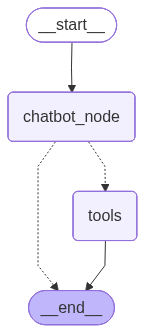

In [50]:
graph = builder.compile()

from IPython.display import Image,display

display(graph)


In [55]:
state1 = graph.invoke({"messages": [{"role":"user","content":"What is the current price of AMZN stock right now?"}]})

print(state1["messages"][-1].content)

400.5


In [54]:
state = graph.invoke({"messages": [{"role":"user","content":"New Yprk is in which continent?"}]})

print(state["messages"][-1].content)

[{'type': 'text', 'text': 'New York is in **North America**. It is a state in the Northeastern United States, and its most populous city, New York City, is also located there.', 'extras': {'signature': 'EvgBCvUBAb4+9vvFakYOg8ZcmrWdLEmhcRxg/zYIOu4pCBMN3lb3gO5AdJ4B2AOGBArdHYDZCnCOqNfl1GYS1U7dPyYVF0e69rbd17jDKutWCRfoyJpaDUST3Zi2WggdiFDQwyAX/QeXcFJJi5C5QOUToFg2kt1i2xrNtIPvfiYyXe7agbY8UPKmzcrDZNgrcNQdEHA3F30aPA1ixrNBs9uqtv8baBpvdIxyrt0AC23FXxCuVrEDglu5R6GNUUXqL7Yu2pXHRARettGn25BrpQyaGB7c2HLeK14fM1qtQtrlwwfjLAhlo2SGy06adyrOnMkGucdjwBMu2S8='}}]
